In [14]:
!pip install scikit-learn



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sklearn

print(sklearn.__version__)

1.9.0


In [4]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [5]:
df = pd.read_excel(
    r"C:\Users\HYPE AMD\Downloads\Dataset nilai siswa.xlsx"
)

df = df.dropna()

df.head()

,Nama,Matematika,Fisika,Biologi,Kimia,Bahasa Inggris,Bahasa Indonesia,Sejarah,PKN,Ekonomi,Sosiologi
0,Aldo,80.0,78.0,85.0,82.0,76.0,88.0,79.0,90.0,81.0,82.0
1,Bella,90.0,92.0,89.0,91.0,87.0,93.0,88.0,95.0,90.0,91.0
2,Cahyo,70.0,75.0,72.0,68.0,74.0,80.0,73.0,78.0,71.0,72.0
3,Dina,85.0,88.0,84.0,86.0,82.0,90.0,84.0,91.0,87.0,86.0
4,Eko,76.0,74.0,78.0,72.0,75.0,77.0,74.0,79.0,76.0,75.0


In [6]:
sains = [
    "Matematika",
    "Fisika",
    "Biologi",
    "Kimia"
]

sosial = [
    "Sejarah",
    "PKN",
    "Ekonomi",
    "Sosiologi"
]

bahasa = [
    "Bahasa Inggris",
    "Bahasa Indonesia"
]

df["Rata_Sains"] = df[sains].mean(axis=1)
df["Rata_Sosial"] = df[sosial].mean(axis=1)
df["Rata_Bahasa"] = df[bahasa].mean(axis=1)

def bidang_dominan(row):

    nilai = {
        "Sains": row["Rata_Sains"],
        "Sosial": row["Rata_Sosial"],
        "Bahasa": row["Rata_Bahasa"]
    }

    return max(nilai, key=nilai.get)

df["Bidang_Dominan"] = df.apply(
    bidang_dominan,
    axis=1
)

In [19]:
X = df[
    [
        "Matematika",
        "Fisika",
        "Biologi",
        "Kimia",
        "Bahasa Inggris",
        "Bahasa Indonesia",
        "Sejarah",
        "PKN",
        "Ekonomi",
        "Sosiologi"
    ]
]

y = df["Bidang_Dominan"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
start_time = time.perf_counter()

In [21]:
model = DecisionTreeClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [23]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

start_time = time.perf_counter()

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

end_time = time.perf_counter()

In [13]:
akurasi = accuracy_score(y_test, y_pred)

waktu = end_time - start_time

print(f"Akurasi : {akurasi*100:.2f}%")
print(f"Waktu Eksekusi: {waktu:.6f} detik")

Akurasi : 100.00%
Waktu Eksekusi: 0.005720 detik


In [14]:
import pandas as pd

hasil_prediksi = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred
})

hasil_prediksi.to_excel(
    "hasil_decision_tree.xlsx",
    index=False
)

print("File berhasil disimpan")

File berhasil disimpan


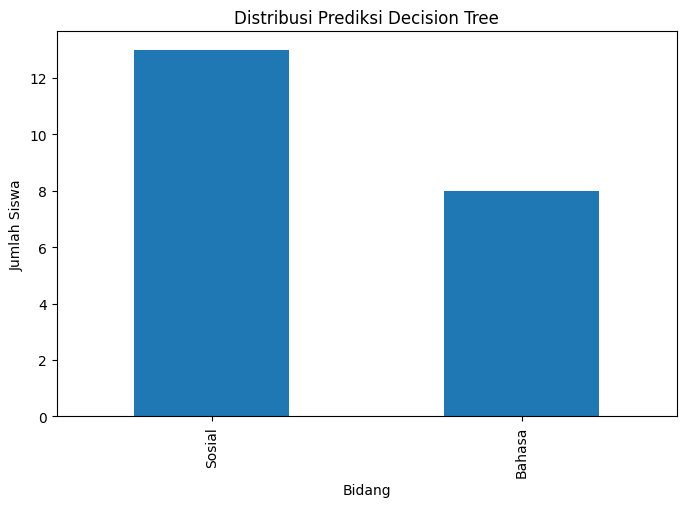

In [15]:
import matplotlib.pyplot as plt

prediksi = pd.Series(y_pred)

plt.figure(figsize=(8,5))

prediksi.value_counts().plot(kind="bar")

plt.title("Distribusi Prediksi Decision Tree")
plt.xlabel("Bidang")
plt.ylabel("Jumlah Siswa")

plt.show()

In [16]:
hasil_prediksi.to_excel(
    "hasil_decision_tree.xlsx",
    index=False
)

In [17]:
hasil_prediksi.to_excel("hasil_decision_tree.xlsx", index=False)
print("File berhasil dibuat")

File berhasil dibuat


In [18]:
import os

os.getcwd()

'C:\\Users\\HYPE AMD'